<a href="https://colab.research.google.com/github/balon14/hockey/blob/main/nhl_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
#import matplotlib.dates as mdates
import matplotlib.pyplot as plt
#import seaborn as sns
from google.colab import files
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.stattools import adfuller
import matplotlib.patches as mpatches
from matplotlib.path import Path

In [ ]:
uploaded = files.upload()

Saving _Points.xlsx to _Points.xlsx
Saving _Price.xlsx to _Price.xlsx
Saving 2026.xlsx to 2026.xlsx


In [ ]:
df26 = pd.read_excel('2026.xlsx')
#df25 = pd.read_excel('2025.xlsx')
#df24 = pd.read_excel('2024.xlsx')
Price = pd.read_excel('_Price.xlsx')
Points = pd.read_excel('_Points.xlsx')
df26

,Дата,Хозяева,Гости,Состав1,Состав2,Игрок1,Игрок2,Счет1,Счет2,Ничья,...,Потери1,Потери2,Перехваты1,Перехваты2,Сила1,Сила2,Вратарь1,Вратарь2,Форма1,Форма2
0,2025-10-08,Флорида,Чикаго,0.00,-0.50,"Barkov A., Nosek T., Tkachuk M.","Brossoit L., Slaggert L., Vlasic A., Weber S.",3,2,NaN,...,17,19,3,4,3,3,Бобровский,Найт,NaN,NaN
1,2025-10-08,Рейнджерс,Питтсбург,0.00,-1.00,NaN,"Blomqvist J., Hayes K., McGroarty R., Rust B.,...",0,3,NaN,...,17,19,4,1,3,2,Шестеркин,Шилов,NaN,NaN
2,2025-10-08,Лос-Анджелес,Колорадо,0.00,0.00,"Burroughs K., Perry C.","Blackwood M., O'Connor L.",1,4,NaN,...,30,23,8,3,2,1,Куемпер,Веджвуд,NaN,NaN
3,2025-10-09,Торонто,Монреаль,0.00,0.00,Woll J.,NaN,5,2,NaN,...,12,13,2,3,3,3,Столарс,Монтембо,NaN,NaN
4,2025-10-09,Вашингтон,Бостон,0.00,0.00,McIlrath D.,NaN,1,3,NaN,...,15,20,3,3,1,3,Томпсон,Свэймэн,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,2026-04-17,Нэшвилл,Анахайм,-3.25,-0.50,"Hague N., Haula E., Josi R., Marchessault J.","Gudas R., Harkins J., Johnston R., Mrazek P.",4,5,NaN,...,16,13,5,5,3,2,Сарос,Хуссо,П-В-П-В-ПО-В-ВО-П-П-П-В-ВО-В-В-ВО-П-ПО-В-П-В-П...,П-ПО-В-П-П-П-П-ПО-П-ПО-В-ВО-В-ПО-В-П-П-В-П-ВО-...
1308,2026-04-17,Юта,Сент-Луис,-3.25,0.00,"Durzi S., Guenther D., Hayton B., McBain J.",Krug T.,3,5,NaN,...,15,12,2,5,2,3,Веймелка,Хофер,В-П-П-В-ВО-В-В-В-П-П-ВО-П-В-В-П-ПО-П-ПО-ВО-В-В...,В-В-В-П-П-В-В-ПО-П-В-ВО-В-В-ПО-П-ВО-В-ПО-В-ВО-...
1309,2026-04-17,Калгари,Лос-Анджелес,-1.50,-1.75,"Bahl K., Bean J., Cooley D., Hanley J., Honzek...","Fiala K., Kuzmenko A., Malott J., Turcotte A.",3,1,NaN,...,26,13,3,6,4,2,Сергеев,Форсберг,П-В-П-П-ПО-В-П-П-В-ПО-ВО-ВО-В-ВО-П-П-В-П-П-В-П...,ПО-В-В-В-ВО-ВО-ПО-ВО-П-В-ПО-ПО-П-ПО-В-П-В-ПО-В...
1310,2026-04-17,Эдмонтон,Ванкувер,-2.25,-0.75,"Dickinson J., Draisaitl L., Janmark M., Jones M.","Chytil F., Demko T., Forbort D., Kane E., Lekk...",6,1,NaN,...,9,15,6,2,2,4,Ингрэм,Ланкинен,ПО-П-В-ПО-П-В-В-В-ВО-В-П-П-В-В-П-П-В-В-П-ВО-П-...,ВО-ВО-ВО-П-П-П-П-В-П-П-П-П-П-П-В-П-ВО-П-ПО-В-П...


#Сопоставление датасетов Points и Price

Добавляем в основной датасет данные из двух других:
- В одном очки каждого игрока, во втором их стоимость
- Сначала сводим все ФИО к единому формату
- Затем объединяем и сводим с основным датасетом

In [ ]:
Points = Points.merge(
    Price[['Игрок', '25-26', 'Возраст']],
    on='Игрок',
    how='inner'
)

In [ ]:
#форматирование имени фамилии на фамилия инициалы

def format_name(full_name: str) -> str:
    full_name = str(full_name).strip()
    parts = full_name.split()

    # Ожидаем минимум 2 части: имя и фамилия (типично: "Connor McDavid")
    if len(parts) < 2:
        return full_name

    first_name = parts[0]          # "Connor"
    last_name = " ".join(parts[1:])  # "McDavid" (на случай если фамилия из нескольких слов)

    return f"{last_name} {first_name[0]}."

Points["Игрок"] = Points["Игрок"].apply(format_name)

In [ ]:
# 1. Приводим стоимость к числовому типу
Points['Очки'] = pd.to_numeric(Points['Очки'], errors='coerce').fillna(0)

# 2. Создаём словарь: Фамилия → Стоимость
cost_dict = Points.set_index('Игрок')['Очки'].to_dict()

# 3. Функция для подсчёта суммы по нескольким игрокам
def calculate_cost(players_str):
    if pd.isna(players_str) or players_str == '':
        return 0.0

    # Разбиваем строку по запятой и очищаем пробелы
    player_list = [p.strip() for p in str(players_str).split(',')]

    # Суммируем стоимости
    total = sum(cost_dict.get(player, 0) for player in player_list)
    return total

# 4. Применяем функцию
df26['Стоимость1'] = df26['Игрок1'].apply(calculate_cost)
df26['Стоимость2'] = df26['Игрок2'].apply(calculate_cost)

In [ ]:
Points['25-26'] = pd.to_numeric(Points['25-26'], errors='coerce').fillna(0)
Points['Очки']   = pd.to_numeric(Points['Очки'],   errors='coerce').fillna(0)

# 2. Создаём два словаря
cost_dict = Points.set_index('Игрок')['25-26'].to_dict()   # для стоимости
points_dict = Points.set_index('Игрок')['Очки'].to_dict()   # для очков

# 3. Универсальная функция
def calculate_sum(players_str, value_dict):
    if pd.isna(players_str) or str(players_str).strip() == '':
        return 0.0

    # Разбиваем игроков и очищаем пробелы
    player_list = [p.strip() for p in str(players_str).split(',')]

    # Суммируем
    total = sum(value_dict.get(player, 0) for player in player_list)
    return total

# 4. Применяем для обеих колонок
df26['Стоимость1'] = df26['Игрок1'].apply(calculate_sum, args=(cost_dict,))
df26['Стоимость2'] = df26['Игрок2'].apply(calculate_sum, args=(cost_dict,))

df26['Очки1']      = df26['Игрок1'].apply(calculate_sum, args=(points_dict,))
df26['Очки2']      = df26['Игрок2'].apply(calculate_sum, args=(points_dict,))

# Проверка результата
print(df26[['Игрок1', 'Стоимость1', 'Очки1',
            'Игрок2', 'Стоимость2', 'Очки2']].head(8))

                            Игрок1  Стоимость1  Очки1  \
0  Barkov A., Nosek T., Tkachuk M.  10275000.0   34.0   
1                              NaN         0.0    0.0   
2           Burroughs K., Perry C.   1000000.0   36.0   
3                          Woll J.         0.0    0.0   
4                      McIlrath D.    800000.0    0.0   
5  Hyman Z., Janmark M., Walman J.   3400000.0   20.0   
6                   Pietrangelo A.         0.0    0.0   
7  Barkov A., Nosek T., Tkachuk M.  10275000.0   34.0   

                                              Игрок2  Стоимость2  Очки2  
0      Brossoit L., Slaggert L., Vlasic A., Weber S.   5500000.0   28.0  
1  Blomqvist J., Hayes K., McGroarty R., Rust B.,...   9646429.0   75.0  
2                          Blackwood M., O'Connor L.   2500000.0    2.0  
3                                                NaN         0.0    0.0  
4                                                NaN         0.0    0.0  
5                          Huberdeau J., P

In [ ]:
df26.to_excel('df.xlsx', index=False)

#Пропуски

- Заполнение пустых значений в столбцах
- В некоторых строках присутствуют пустые значения и возможно деление на 0
- Чтобы избежать строк с ошибками заполняем данные строки на 0

In [ ]:
columns = ['ППХ', 'ППГ', 'ПКХ', 'ПКГ']

df26[columns] = df26[columns].fillna(0)

In [ ]:
print(df26[['ППХ', 'ППГ', 'ПКХ', 'ПКГ']].isna().sum())

ППХ    0
ППГ    0
ПКХ    0
ПКГ    0
dtype: int64


In [ ]:
df26 = df26.tail(250)

In [ ]:
df26

,Дата,Хозяева,Гости,Состав1,Состав2,Расст1,Расст2,Счет1,Счет2,Ничья,...,Потери1,Потери2,Перехваты1,Перехваты2,Сила1,Сила2,Вратарь1,Вратарь2,Форма1,Форма2
389,2025-11-29,Даллас,Юта,-0.25,0.00,NaN,NaN,4,3,NaN,...,14,18,6,3,1,2,Оттингер,Ванечек,В-В-ПО-В-П-В-В-ВО-В-В-П-ВО-ПО-ПО-В-В-В-ПО-П-П-...,П-В-В-П-ПО-ПО-ПО-В-П-П-П-ВО-П-П-В-В-В-ВО-В-В-В...
390,2025-11-29,Рейнджерс,Тампа-Бэй,0.00,-1.00,280.0,NaN,1,4,NaN,...,13,19,3,3,3,1,Шестеркин,Йоханссон,В-В-В-П-П-П-П-ВО-В-В-П-В-П-ВО-ВО-В-П-ПО-П-В-ПО...,В-В-В-В-ВО-В-П-В-П-В-В-П-В-ВО-В-ВО-В-П-П-ПО-ПО...
391,2025-11-29,Колорадо,Монреаль,-0.75,-0.25,991.0,748.0,7,2,NaN,...,18,17,5,4,1,3,Блэквуд,Добес,ПО-В-В-В-В-В-В-В-ВО-В-В-ПО-В-В-ПО-П-ПО-ПО-В-В-...,В-В-В-П-ПО-П-П-П-В-ПО-ПО-ВО-ВО-В-П-ВО-В-П-ВО-В...
392,2025-11-30,Сиэтл,Эдмонтон,-0.25,-0.50,NaN,NaN,0,4,NaN,...,15,15,5,4,3,2,Даккор,Скиннер,П-ПО-ВО-В-П-В-В-ПО-П-ВО-П-В-ПО-ПО-В-В-П-П-ВО-П...,П-В-ПО-П-П-ВО-П-ВО-ВО-П-ПО-П-ВО-ПО-В-ПО-П-В-ВО...
393,2025-11-30,Питтсбург,Торонто,-0.50,0.00,184.0,245.0,2,7,NaN,...,11,19,2,6,2,3,Шилов,Хилдеби,ВО-В-ПО-П-В-ПО-П-ПО-В-П-П-В-ПО-В-ПО-В-В-В-В-П-...,П-ВО-П-ПО-ВО-П-ПО-П-П-П-В-В-В-П-В-ВО-П-П-ПО-ВО...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634,2026-01-02,Лос-Анджелес,Тампа-Бэй,0.00,-0.50,NaN,NaN,3,5,NaN,...,19,10,6,2,2,1,Куемпер,Йоханссон,П-В-П-П-В-П-П-ПО-ПО-В-В-П-П-ВО-ПО-В-ПО-ПО-П-В-...,ВО-ВО-П-В-В-ПО-П-П-ВО-В-ВО-П-В-В-В-П-ПО-П-ВО-П...
635,2026-01-02,Питтсбург,Детройт,-0.75,0.00,NaN,NaN,4,3,ОТ,...,11,11,4,4,3,1,Шилов,Талбот,В-В-П-ВО-П-П-П-ПО-ПО-П-ПО-ПО-В-В-П-ВО-В-ПО-П-В...,В-ВО-П-ВО-ВО-В-П-В-В-П-В-В-В-ПО-В-ПО-П-П-П-ВО-...
636,2026-01-02,Торонто,Виннипег,-1.50,0.00,NaN,NaN,6,5,NaN,...,15,14,6,4,4,4,Уолл,Комри,В-ПО-В-В-П-П-В-П-ПО-В-ПО-В-В-В-П-ВО-П-ПО-ВО-П-...,П-П-ПО-ПО-П-П-ПО-В-П-П-П-В-ПО-П-В-П-П-П-П-В-ВО...
637,2026-01-02,Чикаго,Даллас,-1.75,-0.25,NaN,NaN,4,3,NaN,...,15,17,7,4,4,1,Найт,Оттингер,ПО-П-ВО-П-П-П-П-П-П-В-П-П-В-ПО-В-П-ПО-П-П-П-В-...,П-ПО-ПО-В-В-В-В-П-П-В-ВО-В-В-ПО-В-В-В-В-ПО-В-П...


#Проверка точности заполнения

Проверяем, все ли команды учтены (количество значений у каждой команды должно быть одинаковым).

In [ ]:
value_counts_A = df[24].value_counts()
print("Количество уникальных значений в столбце 'A':")
print(value_counts_A)

Количество уникальных значений в столбце 'A':
24
1    648
2    393
3    271
Name: count, dtype: int64


In [ ]:
value_counts_A = df[25].value_counts()
print("Количество уникальных значений в столбце 'A':")
print(value_counts_A)

Количество уникальных значений в столбце 'A':
25
1    652
2    389
3    271
Name: count, dtype: int64


In [ ]:
value_counts_A = df['К2'].value_counts()
print("Количество уникальных значений в столбце 'A':")
print(value_counts_A)

Количество уникальных значений в столбце 'A':
К2
Сент-Луис       41
Бостон          41
Чикаго          41
Торонто         41
Рейнджерс       41
Виннипег        41
Колорадо        41
Калгари         41
Флорида         41
Монреаль        41
Лос-Анджелес    41
Юта             41
Даллас          41
Коламбус        41
Питтсбург       41
Тампа-Бэй       41
Филадельфия     41
Оттава          41
Нэшвилл         41
Сиэтл           41
Анахайм         41
Айлендерс       41
Миннесота       41
Детройт         41
Эдмонтон        41
Ванкувер        41
Вегас           41
Сан-Хосе        41
Вашингтон       41
Каролина        41
Нью-Джерси      40
Баффало         40
Name: count, dtype: int64


In [ ]:
value_counts_A = df['у'].value_counts()
print("Количество уникальных значений в столбце 'A':")
print(value_counts_A)

Количество уникальных значений в столбце 'A':
у
1.0    345
3.0    271
2.0    187
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Дата              1312 non-null   datetime64[ns]
 1   Хозяева           1312 non-null   int64         
 2   Гости             1312 non-null   int64         
 3   Счет              1312 non-null   object        
 4   Результат         1312 non-null   int64         
 5   Сила              1312 non-null   int64         
 6   Хозяева (топ 16)  1312 non-null   int64         
 7   Гости (топ 16)    1312 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(1)
memory usage: 82.1+ KB


In [ ]:
#пропуски

df.isna().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
Unnamed: 2,0
Unnamed: 3,0
Unnamed: 4,0
Unnamed: 5,1047


In [ ]:
# дубликаты

print('Дубликатов =', df.duplicated().sum())

Дубликатов = 0


#Вратари

У каждой команды от одного до четырех вратарей, разделяем вратарей на основного (1), запасного (2) и резервного (3).

In [ ]:
mapping = {
    # Первый список - код 1
    'Веджвуд': 1,
    'Оттингер': 1,
    'Густавссон': 1,
    'Достал': 1,
    'Шмид': 1,
    'Джарри': 1,
    'Куемпер': 1,
    'Веймелка': 1,
    'Аскаров': 1,
    'Биннингтон': 1,
    'Хофер': 1,
    'Сарос': 1,
    'Вольф': 1,
    'Хеллебайк': 1,
    'Ланкинен': 1,
    'Даккор': 1,
    'Найт': 1,
    'Бусси': 1,
    'Андерсен': 1,
    'Гибсон': 1,
    'Талбот': 1,
    'Томпсон': 1,
    'Добес': 1,
    'Сорокин': 1,
    'Владар': 1,
    'Василевский': 1,
    'Аллен': 1,
    'Маркстрём': 1,
    'Свэймэн': 1,
    'Бобровский': 1,
    'Уллмарк': 1,
    'Шестеркин': 1,
    'Скиннер': 1,
    'Лайон': 1,
    'Хилдеби': 1,
    'Столарс': 1,
    'Гривз': 1,
    'Валисевский': 1,
    'Бобровский': 1,

    # Второй список - код 2
    'Блэквуд': 2,
    'Десмит': 2,
    'Уоллстедт': 2,
    'Мразек': 2,
    'Хуссо': 2,
    'Линдбом': 2,
    'Харт': 2,
    'Хилл': 2,
    'Пикар': 2,
    'Форсберг': 2,
    'Ванечек': 2,
    'Неделькович': 2,
    'Аннунен': 2,
    'Кули': 2,
    'Комри': 2,
    'Демко': 2,
    'Грубауэр': 2,
    'Мюррей': 2,
    'Седерблум': 2,
    'Кочетков': 2,
    'Линдгрен': 2,
    'Монтембо': 2,
    'Риттич': 2,
    'Эрссон': 2,
    'Йоханссон': 2,
    'Корписало': 2,
    'Тарасов': 2,
    'Мерилайнен': 2,
    'Куик': 2,
    'Шилов': 2,
    'Луукконен': 2,
    'Эллис': 2,
    'Уолл': 2,
    'Примо': 2,
    'Мерзликин': 2,
     # Третий список - код 3
    'Сергеев': 3,
    'Кокко': 3,
    'Ахтямов': 3,
    'Остман': 3,
    'Ингрэм': 3,
    'Патера': 3,
    'Комессо': 3,
    'Копли': 3,
    'Толопило': 3,
    'Раймер': 3,
    'Фовиер': 3,
    'Броссуа': 3,
    'Колосов': 3,
    'Милич': 3,
    'Коммессо': 3,
    'Мартин': 3,
    'Минер': 3,
    'Халверсон': 3,
    'Доус': 3,
    'Сёгаард': 3,
    'Стивенсон': 3,
    'Гаранд': 3,
    'Мурашов': 3,

}
# Теперь применяем к DataFrame
df26['Вратарь3'] = df26['Вратарь1'].map(mapping).fillna(0).astype(int)
df26['Вратарь4'] = df26['Вратарь2'].map(mapping).fillna(0).astype(int)

#Подсчет очков

Делаем автоматический подсчет очков по результату матча:
- Победа = 2 очка
- Поражение = 1 очко
- Победа ОТ = 2 очка
- Поражение ОТ = 1 очко

In [ ]:
def calculate_ochki1(row):
    # Сравниваем счёт1 и счёт2
    if row['Счет1'] > row['Счет2']:
        return 2
    elif row['Счет1'] < row['Счет2']:
        return 0
    else:
        # Если счёт равный — смотрим колонку "ничья"
        nichya = row['Ничья']
        # На случай, если в колонке значения могут быть и строкой "1"/"2", и числом 1/2
        if nichya in [1, '1']:
            return 2
        elif nichya in [2, '2']:
            return 1
        else:
            # На всякий случай (если ничья не заполнена или другое значение)
            return 0

# Создаём новую колонку, проходя по каждой строке
df26['Очки1'] = df26.apply(calculate_ochki1, axis=1)

# Если хотите посмотреть результат
print(df26[['Хозяева', 'Счет1', 'Счет2', 'Ничья', 'Очки1']].head())

        Хозяева  Счет1  Счет2  Ничья  Очки1
0       Флорида      3      2    NaN      2
1     Рейнджерс      0      3    NaN      0
2  Лос-Анджелес      1      4    NaN      0
3       Торонто      5      2    NaN      2
4     Вашингтон      1      3    NaN      0


In [ ]:
def calculate_ochki2(row):
    # Сравниваем счёт1 и счёт2
    if row['Счет1'] > row['Счет2']:
        return 0
    elif row['Счет1'] < row['Счет2']:
        return 2
    else:
        # Если счёт равный — смотрим колонку "ничья"
        nichya = row['Ничья']
        # На случай, если в колонке значения могут быть и строкой "1"/"2", и числом 1/2
        if nichya in [1, '1']:
            return 1
        elif nichya in [2, '2']:
            return 2
        else:
            # На всякий случай (если ничья не заполнена или другое значение)
            return 0

# Создаём новую колонку, проходя по каждой строке
df26['Очки2'] = df26.apply(calculate_ochki2, axis=1)

# Если хотите посмотреть результат
print(df26[['Гости', 'Счет1', 'Счет2', 'Ничья', 'Очки2']].head())

       Гости  Счет1  Счет2  Ничья  Очки2
0     Чикаго      3      2    NaN      0
1  Питтсбург      0      3    NaN      2
2   Колорадо      1      4    NaN      2
3   Монреаль      5      2    NaN      0
4     Бостон      1      3    NaN      2


In [ ]:
df26 = df26.sort_index()  # на всякий случай сохраняем исходный порядок

df26['матч_номер_дома1'] = df26.groupby('Хозяева').cumcount() + 1
df26['Очки1_накоп'] = df26.groupby('Хозяева')['Очки1'].cumsum()

print(df26[['Хозяева', 'матч_номер_дома1', 'Очки1', 'Очки1_накоп']])

           Хозяева  матч_номер_дома1  Очки1  Очки1_накоп
0          Флорида                 1      2            2
1        Рейнджерс                 1      0            0
2     Лос-Анджелес                 1      0            0
3          Торонто                 1      2            2
4        Вашингтон                 1      0            0
...            ...               ...    ...          ...
1307       Нэшвилл                41      0           45
1308           Юта                41      0           47
1309       Калгари                41      2           51
1310      Эдмонтон                41      2           49
1311      Колорадо                41      2           58

[1312 rows x 4 columns]


In [ ]:
df26 = df26.sort_index()  # на всякий случай сохраняем исходный порядок

df26['матч_номер_дома2'] = df26.groupby('Гости').cumcount() + 1
df26['Очки2_накоп'] = df26.groupby('Гости')['Очки2'].cumsum()

print(df26[['Гости', 'матч_номер_дома2', 'Очки2', 'Очки2_накоп']])

             Гости  матч_номер_дома2  Очки2  Очки2_накоп
0           Чикаго                 1      0            0
1        Питтсбург                 1      2            2
2         Колорадо                 1      2            2
3         Монреаль                 1      0            0
4           Бостон                 1      2            2
...            ...               ...    ...          ...
1307       Анахайм                41      2           40
1308     Сент-Луис                41      2           39
1309  Лос-Анджелес                41      0           51
1310      Ванкувер                41      0           35
1311         Сиэтл                41      0           36

[1312 rows x 4 columns]


#Подсчет серии Д-Г

У каждой команды идёт серия домашних и гостевых матчей. Допустим три домашних, затем два гостевых. В результате у команды будет серия: Д1 Д2 Д3 Г1 Г2

In [ ]:
from collections import defaultdict

# ====================== ОСНОВНАЯ ЛОГИКА ======================

home_streak = defaultdict(int)   # серия домашних матчей
away_streak = defaultdict(int)   # серия гостевых матчей

result_column = []

for _, row in df26.iterrows():
    хозяин = row['Хозяева']
    гость = row['Гости']

    # Домашняя серия
    номер_дома = home_streak[хозяин] + 1
    home_streak[хозяин] = номер_дома
    away_streak[хозяин] = 0

    # Гостевая серия
    номер_в_гостях = away_streak[гость] + 1
    away_streak[гость] = номер_в_гостях
    home_streak[гость] = 0

    # Формируем строку в формате "Д2-Г1"
    combined = f"Д{номер_дома}-Г{номер_в_гостях}"
    result_column.append(combined)

# Добавляем новую колонку
df26['Match_Number'] = result_column

#ФОРМА В-П-В

В зависимости от результата матча команде присваивается статус, при выигрыше "В", при проигрыше "П", при ничьей "ВО" или "ПО". Данные накапливаются в колонке "Форма 1\2"

In [ ]:
# Создаём колонки
df['Форма1'] = ''
df['Форма2'] = ''

# Словарь для накопления формы (последний матч будет в начале)
team_forms = defaultdict(list)   # используем список, чтобы потом легко соединять

for idx, row in df.iterrows():
    home = row['Хозяева']
    guest = row['Гости']
    score1 = row['Счет1']
    score2 = row['Счет2']
    nichya = row.get('Ничья', 0)

    # Определяем результат текущего матча (в верхнем регистре)
    if score1 > score2:
        result_home = 'В'
        result_guest = 'П'
    elif score1 < score2:
        result_home = 'П'
        result_guest = 'В'
    else:
        # Ничья / овертайм
        if str(nichya).strip() in ['1', '1.0', 1]:
            result_home = 'ВО'
            result_guest = 'ПО'
        else:
            result_home = 'ПО'
            result_guest = 'ВО'

    # === Записываем предыдущую форму в колонки (разделённую "-") ===
    current_form_home = '-'.join(team_forms[home]) if team_forms[home] else ''
    current_form_guest = '-'.join(team_forms[guest]) if team_forms[guest] else ''

    df.at[idx, 'Форма1'] = current_form_home
    df.at[idx, 'Форма2'] = current_form_guest

    # === Добавляем результат текущего матча в начало списка ===
    team_forms[home].insert(0, result_home)
    team_forms[guest].insert(0, result_guest)

#Интеграция колонок "ничья"

Добавляем колонку "ничья" в датасет. А также накапливаем количество ничьих за пройденные матчей. И высчитываем количество матчей до ничьей, при наступлении ничьей результат обнуляется.

In [ ]:
# Определяем, была ли ничья в матче
df26['Is_Draw'] = df26['Ничья'].notna() & df26['Ничья'].isin([1, 2])

# ====================== LONG FORMAT ======================
home = df26[['Дата', 'Хозяева', 'Is_Draw']].rename(columns={'Хозяева': 'Team'}).copy()
away = df26[['Дата', 'Гости',   'Is_Draw']].rename(columns={'Гости': 'Team'}).copy()

long = pd.concat([home, away], ignore_index=True)
long = long.sort_values(by=['Team', 'Дата']).reset_index(drop=True)

# ====================== ДВЕ ОТДЕЛЬНЫЕ ФУНКЦИИ ======================

def calculate_streak(group):
    """Расчёт текущей серии без ничьих (начинается с 0)"""
    streak = 0
    result = []
    for is_draw in group:
        result.append(streak)          # записываем значение до обновления
        if is_draw:
            streak = 0
        else:
            streak += 1
    return result


def calculate_max_streak(group):
    """Расчёт максимальной серии без ничьих за всё время"""
    current = 0
    max_streak = 0
    result = []
    for is_draw in group:
        if is_draw:
            current = 0
        else:
            current += 1
        max_streak = max(max_streak, current)
        result.append(max_streak)
    return result


# Применяем функции
long['Streak'] = long.groupby('Team')['Is_Draw'].transform(calculate_streak)
long['Max_Streak'] = long.groupby('Team')['Is_Draw'].transform(calculate_max_streak)

# ====================== ПЕРЕНОС ОБРАТНО В df ======================
streak_map = long.set_index(['Дата', 'Team'])['Streak'].to_dict()
max_map = long.set_index(['Дата', 'Team'])['Max_Streak'].to_dict()

df26['Streak_Хозяева']     = df26.apply(lambda r: streak_map.get((r['Дата'], r['Хозяева']), 0), axis=1)
df26['Streak_Гости']       = df26.apply(lambda r: streak_map.get((r['Дата'], r['Гости']),   0), axis=1)

df26['Max_Streak_Хозяева'] = df26.apply(lambda r: max_map.get((r['Дата'], r['Хозяева']), 0), axis=1)
df26['Max_Streak_Гости']   = df26.apply(lambda r: max_map.get((r['Дата'], r['Гости']),   0), axis=1)

# Удаляем временную колонку
df26 = df26.drop(columns=['Is_Draw'])

#Среднее количество шайб

In [ ]:
average_df = df26.groupby('Хозяева', as_index=False).agg(ШХ=('Счет1', 'mean'))
average_df1 = df26.groupby('Гости', as_index=False).agg(ШГ=('Счет2', 'mean'))
df26 = pd.merge(df26, average_df, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df1, on='Гости', how='left')

In [ ]:
average_df = df26.groupby('Хозяева', as_index=False).agg(ПШХ=('Счет2', 'mean'))
average_df1 = df26.groupby('Гости', as_index=False).agg(ПШГ=('Счет1', 'mean'))
df26 = pd.merge(df26, average_df, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df1, on='Гости', how='left')

#Среднее Штрафное время

In [ ]:
average_df2 = df26.groupby('Хозяева', as_index=False).agg(Ср_Штраф_Х=('Штр. Время Хоз', 'mean'))
average_df3 = df26.groupby('Гости', as_index=False).agg(СР_Штраф_Г=('Штр. Время Гос', 'mean'))
df26 = pd.merge(df26, average_df2, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df3, on='Гости', how='left')

#Среднее количество бросков

In [ ]:
average_df3 = df26.groupby('Хозяева', as_index=False).agg(Ср_Броски_Х=('Броски1', 'mean'))
average_df4 = df26.groupby('Гости', as_index=False).agg(СР_Броски_Г=('Броски2', 'mean'))
df26 = pd.merge(df26, average_df3, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df4, on='Гости', how='left')

#Пропущенные шайбы дома (среднее)

In [ ]:
df26['пропущено шайб дома'] = df26['Счет2']
df26['пропущено шайб в гостях'] = df26['Счет1']


In [ ]:
ср_проп_Х = df26['пропущено шайб дома'].mean()
ср_проп_Г = df26['пропущено шайб в гостях'].mean()


In [ ]:
#df26['среднее пропущено Х'] = ср_проп_Х
#df26['среднее пропущено Г'] = ср_проп_Г

In [ ]:
df26

,Дата,Хозяева,Гости,Счет1,Счет2,Ничья,П1,X,П2,Кто победил,...,Форма1,Форма2,ШХ_x,ШГ_x,ПШХ_x,ПШГ_x,ШХ_y,ШГ_y,ПШХ_y,ПШГ_y
0,2025-11-22,Питтсбург,Миннесота,0,5,NaN,2.25,4.40,2.60,2,...,В-ПО-П-ПО-В-П-П-В-ПО-В-ПО-В-В-В-В-П-П-В-В,ВО-ВО-В-ПО-В-В-П-ВО-В-П-ПО-ПО-П-П-В-ПО-П-П-ВО-П-В,3.000000,3.125000,4.200000,1.750000,2.888889,3.125000,4.666667,1.750000
1,2025-11-22,Баффало,Чикаго,9,3,NaN,1.90,4.40,3.35,1,...,П-В-ВО-П-П-П-П-ПО-ВО-ПО-ПО-ПО-В-В-П-В-В-П-П-П,П-В-В-ПО-В-В-В-П-ПО-П-В-П-В-ВО-ПО-В-В-П-ПО-П,4.285714,2.000000,2.857143,4.777778,4.600000,2.000000,2.600000,4.777778
2,2025-11-22,Виннипег,Каролина,3,4,NaN,3.25,4.40,1.95,2,...,В-ВО-П-В-П-П-П-В-В-ВО-П-В-П-В-В-В-В-В-П,ПО-В-ПО-ВО-П-В-В-В-В-П-В-П-П-ВО-ПО-ВО-В-В-ВО-В,3.125000,3.125000,3.000000,2.750000,2.857143,3.166667,3.142857,2.833333
3,2025-11-22,Лос-Анджелес,Бостон,1,2,ОТ,1.90,4.30,3.45,3,...,ПО-П-В-ВО-В-В-П-В-П-ПО-В-В-ПО-ВО-ВО-ПО-П-ПО-П-...,П-П-В-П-В-В-ВО-ВО-В-ВО-В-П-В-П-П-П-П-П-П-В-ВО-В,2.000000,3.200000,1.571429,3.200000,2.000000,3.285714,1.571429,3.000000
4,2025-11-22,Детройт,Коламбус,4,3,ОТ,2.25,4.40,2.60,3,...,П-В-В-ПО-В-П-П-П-ВО-П-ВО-В-В-П-П-В-ВО-В-В-В-П,ВО-П-ВО-ПО-В-ВО-ПО-П-П-П-В-В-ВО-ВО-П-В-В-П-П-В-П,3.300000,2.700000,4.000000,3.800000,3.166667,2.666667,4.166667,4.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,2025-12-20,Анахайм,Даллас,3,8,NaN,2.50,4.40,2.35,2,...,ПО-В-П-П-ВО-В-ВО-П-В-П-ВО-П-ВО-П-В-ВО-П-П-П-В-...,В-В-П-П-В-ВО-В-В-ПО-В-В-В-В-ПО-В-П-В-В-ВО-В-В-...,3.600000,4.250000,3.900000,2.416667,3.857143,4.111111,4.428571,2.777778
218,2025-12-20,Вашингтон,Детройт,2,5,NaN,2.00,4.40,3.10,2,...,В-П-П-ПО-В-ПО-В-В-В-В-В-В-П-В-В-В-ПО-П-В-П-П-В...,П-В-В-П-В-В-В-ПО-В-ПО-П-П-П-ВО-П-В-В-ПО-В-П-П-...,3.363636,3.400000,2.454545,2.600000,3.250000,3.555556,2.375000,2.777778
219,2025-12-20,Рейнджерс,Филадельфия,5,4,ОТ,2.18,4.15,2.80,3,...,ВО-П-П-ВО-П-ПО-ПО-В-ВО-П-В-В-В-П-П-П-П-ВО-В-В-...,П-В-ПО-ПО-ПО-В-П-В-П-В-ВО-В-П-В-ВО-П-ВО-ПО-ПО-...,2.300000,3.300000,3.100000,3.500000,2.444444,3.250000,3.222222,3.125000
220,2025-12-20,Миннесота,Эдмонтон,5,2,NaN,2.30,4.30,2.60,1,...,В-В-В-В-В-В-П-П-В-ПО-ВО-ВО-В-В-ВО-ВО-В-ПО-В-В-...,В-В-П-В-В-ПО-В-В-П-В-П-В-ПО-П-П-ВО-П-ВО-ВО-П-П...,3.545455,3.384615,1.818182,3.307692,4.142857,4.000000,1.857143,2.857143


In [ ]:
df26.to_excel('df26.xlsx', index=False)

In [ ]:
df300 = df26.head(200)
value_counts = df300['Серия'].value_counts()

# Общее количество значений
total_count = len(df300)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100

In [ ]:
filtered_df1 = df300[df300['Серия'] == 'Д2-Г1']
win_counts = filtered_df1['Кто победил'].value_counts()
win_percentage = (win_counts / win_counts.sum()) * 100
win_percentage

,count
Кто победил,
1.0,57.894737
3.0,26.315789
2.0,15.789474


In [ ]:
value_counts = df26['Серия'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Серия': {count} ({percentage:.2f}%)")

Количество значений 'Д1-Г1' в столбце 'Серия': 54 (18.00%)
Количество значений 'Д2-Г1' в столбце 'Серия': 33 (11.00%)
Количество значений 'Д1-Г2' в столбце 'Серия': 31 (10.33%)
Количество значений 'Д2-Г2' в столбце 'Серия': 18 (6.00%)
Количество значений 'Д1-Г3' в столбце 'Серия': 15 (5.00%)
Количество значений 'Д3-Г2' в столбце 'Серия': 15 (5.00%)
Количество значений 'Д3-Г1' в столбце 'Серия': 13 (4.33%)
Количество значений 'Д1-Г4' в столбце 'Серия': 12 (4.00%)
Количество значений 'Д3-Г3' в столбце 'Серия': 12 (4.00%)
Количество значений 'Д2-Г3' в столбце 'Серия': 12 (4.00%)
Количество значений 'Д4-Г1' в столбце 'Серия': 10 (3.33%)
Количество значений 'Д4-Г4' в столбце 'Серия': 8 (2.67%)
Количество значений 'Д2-Г5' в столбце 'Серия': 8 (2.67%)
Количество значений 'Д2-Г4' в столбце 'Серия': 7 (2.33%)
Количество значений 'Д2-Г6' в столбце 'Серия': 6 (2.00%)
Количество значений 'Д4-Г2' в столбце 'Серия': 6 (2.00%)
Количество значений 'Д5-Г1' в столбце 'Серия': 5 (1.67%)
Количество значен

In [ ]:
filtered_df = df26[df26['Серия'] == 'Д1-Г6']
win_counts = filtered_df['Кто победил'].value_counts()
win_percentage = (win_counts / win_counts.sum()) * 100
win_percentage

,count
Кто победил,
2.0,100.0


In [ ]:
comparison = df26.groupby('Хозяева')['ШХ'].first().reset_index()
comparison

,Хозяева,ШХ
0,Айлендерс,3.333333
1,Анахайм,3.111111
2,Баффало,4.000000
3,Бостон,3.142857
4,Ванкувер,2.250000
5,Вашингтон,3.500000
6,Вегас,3.500000
7,Виннипег,3.000000
8,Даллас,2.875000
9,Детройт,2.428571


In [ ]:
comparison = df26.groupby('Хозяева')['ПШХ'].first().reset_index()
comparison

,Хозяева,ПШХ
0,Айлендерс,2.888889
1,Анахайм,4.333333
2,Баффало,2.000000
3,Бостон,3.428571
4,Ванкувер,4.000000
5,Вашингтон,3.125000
6,Вегас,3.666667
7,Виннипег,3.142857
8,Даллас,2.625000
9,Детройт,2.571429


In [ ]:
comparison = df26.groupby('Гости')['ШГ'].first().reset_index()
comparison

,Гости,ШГ
0,Айлендерс,2.000000
1,Анахайм,2.714286
2,Баффало,2.909091
3,Бостон,3.428571
4,Ванкувер,2.857143
5,Вашингтон,2.888889
6,Вегас,3.000000
7,Виннипег,2.125000
8,Даллас,4.000000
9,Детройт,3.700000


In [ ]:
comparison = df26.groupby('Гости')['ПШГ'].first().reset_index()
comparison

,Гости,ПШГ
0,Айлендерс,2.666667
1,Анахайм,4.285714
2,Баффало,3.000000
3,Бостон,3.000000
4,Ванкувер,2.285714
5,Вашингтон,3.444444
6,Вегас,3.111111
7,Виннипег,3.625000
8,Даллас,3.142857
9,Детройт,3.000000


In [ ]:
df26

,Дата,Хозяева,Гости,Счет1,Счет2,Ничья,П1,X,П2,Кто победил,...,ШХ,ШГ,Ср_Штраф_Х,СР_Штраф_Г,Ср_Броски_Х,СР_Броски_Г,пропущено шайб дома,пропущено шайб в гостях,среднее пропущено Х,среднее пропущено Г
0,2025-10-08,Флорида,Чикаго,3.0,2.0,NaN,1.65,4.8,4.50,1.0,...,3.800000,3.600000,3.300000,3.000000,31.400000,25.500000,2.0,3.0,3.034591,3.179245
1,2025-10-08,Рейнджерс,Питтсбург,0.0,3.0,NaN,1.75,4.8,4.05,2.0,...,1.444444,2.818182,2.777778,2.818182,26.222222,27.454545,3.0,0.0,3.034591,3.179245
2,2025-10-08,Лос-Анджелес,Колорадо,1.0,4.0,NaN,2.55,4.3,2.45,2.0,...,2.142857,3.900000,3.000000,3.600000,31.285714,31.700000,4.0,1.0,3.034591,3.179245
3,2025-10-09,Торонто,Монреаль,5.0,2.0,NaN,2.02,4.5,3.15,1.0,...,3.642857,3.444444,2.642857,4.111111,26.285714,25.222222,2.0,5.0,3.034591,3.179245
4,2025-10-09,Вашингтон,Бостон,1.0,3.0,NaN,1.95,4.4,3.45,2.0,...,3.181818,3.100000,5.636364,4.500000,29.000000,26.200000,3.0,1.0,3.034591,3.179245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,2025-11-21,Колорадо,Рейнджерс,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.333333,3.333333,3.000000,3.250000,36.111111,27.500000,NaN,NaN,3.034591,3.179245
326,2025-11-21,Юта,Вегас,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.571429,2.750000,3.428571,3.000000,31.285714,27.125000,NaN,NaN,3.034591,3.179245
327,2025-11-21,Анахайм,Оттава,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,3.625000,3.375000,2.875000,27.500000,26.250000,NaN,NaN,3.034591,3.179245
328,2025-11-21,Ванкувер,Даллас,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,3.666667,4.333333,3.000000,30.111111,24.888889,NaN,NaN,3.034591,3.179245


In [ ]:
filtered_df = df26[df26['Хозяева'].str.contains('Виннипег', na=False, case=False)]
filtered_df.head(30)


,Дата,Хозяева,Гости,Счет1,Счет2,Ничья,П1,X,П2,Кто победил,...,Сила1,Сила2,ШХ,ШГ,ПШХ,ПШГ,Ср_Штраф_Х,СР_Штраф_Г,Ср_Броски_Х,СР_Броски_Г
16,2025-10-10,Виннипег,Даллас,4,5,NaN,2.55,4.2,2.40,2,...,3,1,3.363636,3.666667,2.818182,2.533333,3.363636,3.266667,29.636364,25.600000
21,2025-10-11,Виннипег,Лос-Анджелес,3,2,NaN,2.30,4.3,2.65,1,...,3,2,3.363636,3.200000,2.818182,2.733333,3.363636,3.400000,29.636364,28.133333
83,2025-10-19,Виннипег,Нэшвилл,4,1,NaN,1.90,4.4,3.35,1,...,3,4,3.363636,2.636364,2.818182,3.545455,3.363636,3.181818,29.636364,28.272727
118,2025-10-24,Виннипег,Сиэтл,0,3,NaN,1.78,4.7,3.60,2,...,3,3,3.363636,2.615385,2.818182,3.384615,3.363636,3.000000,29.636364,25.769231
125,2025-10-25,Виннипег,Калгари,5,3,NaN,2.18,4.3,2.80,1,...,3,4,3.363636,2.333333,2.818182,3.500000,3.363636,3.666667,29.636364,27.555556
142,2025-10-27,Виннипег,Юта,2,3,NaN,2.10,4.3,2.90,2,...,3,2,3.363636,2.941176,2.818182,3.176471,3.363636,3.235294,29.636364,28.000000
173,2025-10-31,Виннипег,Чикаго,6,3,NaN,1.80,4.6,3.60,1,...,3,3,3.363636,3.384615,2.818182,3.153846,3.363636,3.000000,29.636364,26.461538
181,2025-11-01,Виннипег,Питтсбург,5,2,NaN,2.00,4.4,3.10,1,...,3,2,3.363636,3.142857,2.818182,2.357143,3.363636,3.142857,29.636364,27.428571
310,2025-11-19,Виннипег,Коламбус,5,2,NaN,1.93,4.5,3.25,1,...,3,3,3.363636,3.200000,2.818182,3.400000,3.363636,3.200000,29.636364,31.000000
332,2025-11-22,Виннипег,Каролина,3,4,NaN,3.25,4.4,1.95,2,...,3,1,3.363636,3.153846,2.818182,2.615385,3.363636,4.000000,29.636364,34.076923


In [ ]:
filtered_df1 = df26[df26['Гости'].str.contains('Баффало', na=False, case=False)]
filtered_df1.head(30)


,Дата,Хозяева,Гости,Счет1,Счет2,Ничья,П1,X,П2,Кто победил,...,Сила1,Сила2,ШХ,ШГ,ПШХ,ПШГ,Ср_Штраф_Х,СР_Штраф_Г,Ср_Броски_Х,СР_Броски_Г
29,2025-10-12,Бостон,Баффало,3,1,NaN,2.25,4.3,2.65,1,...,3,4,3.400000,2.636364,3.000000,4.272727,3.400000,3.272727,27.133333,27.090909
94,2025-10-21,Монреаль,Баффало,4,2,NaN,2.13,4.3,2.85,1,...,3,4,3.285714,2.636364,3.857143,4.272727,3.500000,3.272727,25.785714,27.090909
128,2025-10-26,Торонто,Баффало,4,3,ОТ,2.13,4.2,2.90,3,...,3,4,3.533333,2.636364,3.333333,4.272727,2.600000,3.272727,26.466667,27.090909
169,2025-10-31,Бостон,Баффало,4,3,ОТ,2.75,4.4,2.15,3,...,3,4,3.400000,2.636364,3.000000,4.272727,3.400000,3.272727,27.133333,27.090909
238,2025-11-09,Каролина,Баффало,6,3,NaN,1.68,4.7,4.05,1,...,1,4,3.538462,2.636364,3.153846,4.272727,2.846154,3.272727,32.230769,27.090909
266,2025-11-13,Юта,Баффало,5,2,NaN,1.80,4.6,3.60,1,...,2,4,3.363636,2.636364,2.636364,4.272727,3.090909,3.272727,30.727273,27.090909
274,2025-11-14,Колорадо,Баффало,6,3,NaN,1.45,5.5,5.50,1,...,1,4,4.692308,2.636364,2.230769,4.272727,2.769231,3.272727,36.076923,27.090909
289,2025-11-16,Детройт,Баффало,4,5,ОТ,1.95,4.5,3.15,3,...,3,4,3.375000,2.636364,3.687500,4.272727,2.812500,3.272727,31.437500,27.090909
362,2025-11-27,Питтсбург,Баффало,4,2,NaN,2.25,4.5,2.60,1,...,2,4,3.250000,2.636364,3.416667,4.272727,3.000000,3.272727,26.583333,27.090909
398,2025-11-30,Миннесота,Баффало,2,3,ОТ,2.07,4.5,2.90,3,...,1,4,2.933333,2.636364,3.066667,4.272727,2.400000,3.272727,29.600000,27.090909


In [ ]:
df26.to_excel('2026.xlsx', index=False)

In [ ]:
filtered_df.to_excel('vin.xlsx', index=False)
#filtered_df1.to_excel('baf.xlsx', index=False)

#Основная статистика

In [ ]:
value_counts = df24['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df24)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'кто победил': 238 (38.64%)
Количество значений '2' в столбце 'кто победил': 216 (35.06%)
Количество значений '3' в столбце 'кто победил': 162 (26.30%)


In [ ]:
value_counts = df25['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df25)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 238 (38.64%)
Количество значений '2' в столбце 'Кто победил': 216 (35.06%)
Количество значений '3' в столбце 'Кто победил': 162 (26.30%)


In [ ]:
value_counts = df26['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1.0' в столбце 'Кто победил': 304 (39.48%)
Количество значений '2.0' в столбце 'Кто победил': 262 (34.03%)
Количество значений '3.0' в столбце 'Кто победил': 200 (25.97%)


In [ ]:
value_counts = first_227_rows['Кто победил'].value_counts()

# Общее количество значений
total_count = len(first_227_rows)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")


Количество значений '1' в столбце 'Кто победил': 98 (43.17%)
Количество значений '2' в столбце 'Кто победил': 86 (37.89%)
Количество значений '3' в столбце 'Кто победил': 43 (18.94%)


#Угадали или нет

In [ ]:
value_counts = df24['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df24)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Угадали или нет': 649 (49.47%)
Количество значений '2' в столбце 'Угадали или нет': 393 (29.95%)
Количество значений '3' в столбце 'Угадали или нет': 270 (20.58%)


In [ ]:
value_counts = df25['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df25)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

NameError: name 'df25' is not defined

In [ ]:
value_counts = df26['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

Количество значений '1.0' в столбце 'Угадали или нет': 321 (41.69%)
Количество значений '2.0' в столбце 'Угадали или нет': 245 (31.82%)
Количество значений '3.0' в столбце 'Угадали или нет': 200 (25.97%)


#Среднее значение по кэфам

In [ ]:
average_score1 = df24['П1'].mean()
average_score2 = df24['X'].mean()
average_score3 = df24['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score1:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score2:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score3:.2f}")

Среднее значение по столбцу 'П1': 2.45
Среднее значение по столбцу 'X': 4.64
Среднее значение по столбцу 'П2': 2.92


In [ ]:
average_score1 = df25['П1'].mean()
average_score2 = df25['X'].mean()
average_score3 = df25['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score1:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score2:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score3:.2f}")

NameError: name 'df25' is not defined

#Фильтр победа фаворита дома

In [ ]:
# Фильтрация строк
filtered_df26 = df26[(df26['Кто победил'] == 1) & (df26['Угадали или нет'] == 1)]
# Вывод результата
#print(filtered_df26)

In [ ]:
count = filtered_df26.shape[0]  # или len(filtered_df26)
print(count)

126


In [ ]:
average_score3 = filtered_df26['П1'].mean()
average_score4 = filtered_df26['X'].mean()
average_score5 = filtered_df26['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score3:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score4:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score5:.2f}")

Среднее значение по столбцу 'П1': 2.00
Среднее значение по столбцу 'X': 4.45
Среднее значение по столбцу 'П2': 3.25


# Фильтр победа сильных в гостях

In [ ]:
# Фильтрация строк
filtered_df26 = df26[(df26['Кто победил'] == 2) & (df26['Угадали или нет'] == 1)]

# Вывод результата
#print(filtered_df26)

In [ ]:
count = filtered_df26.shape[0]  # или len(filtered_df26)
print(count)

54


In [ ]:
average_score6 = filtered_df26['П1'].mean()
average_score7 = filtered_df26['X'].mean()
average_score8 = filtered_df26['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score6:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score7:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score8:.2f}")

Среднее значение по столбцу 'П1': 2.99
Среднее значение по столбцу 'X': 4.37
Среднее значение по столбцу 'П2': 2.10


# Победа слабых в гостях

In [ ]:
# Фильтрация строк
filtered_df24 = df24[(df24['кто победил'] == 2) & (df24['Угадали или нет'] == 2)]

# Вывод результата
print(filtered_df24)

           Дата       Хозяева        Гости  Счет1  Счет2 Ничья    П1    X  \
1    2023-10-11     Питтсбург       Чикаго      2      4   NaN  1.68  4.8   
9    2023-10-13      Коламбус  Филадельфия      2      4   NaN  2.35  4.4   
28   2023-10-15      Эдмонтон     Ванкувер      3      4   NaN  1.75  5.0   
34   2023-10-17       Торонто       Чикаго      1      4   NaN  1.50  5.3   
36   2023-10-17    Нью-Джерси      Флорида      3      4   NaN  1.95  4.6   
...         ...           ...          ...    ...    ...   ...   ...  ...   
1293 2024-04-16  Лос-Анджелес    Миннесота      1      3   NaN  2.10  4.4   
1294 2024-04-17   Филадельфия    Вашингтон      1      2   NaN  2.25  4.6   
1297 2024-04-17        Бостон       Оттава      1      3   NaN  1.77  4.9   
1306 2024-04-19     Миннесота        Сиэтл      3      4   NaN  1.90  4.8   
1310 2024-04-19         Вегас      Анахайм      1      4   NaN  1.47  5.7   

        П2  кто победил  Угадали или нет  
1     4.00            2         

In [ ]:
average_score9 = filtered_df24['П1'].mean()
average_score10 = filtered_df24['X'].mean()
average_score11 = filtered_df24['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score9:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score10:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score11:.2f}")

Среднее значение по столбцу 'П1': 2.05
Среднее значение по столбцу 'X': 4.60
Среднее значение по столбцу 'П2': 3.21


#Победа слабых дома

In [ ]:
# Фильтрация строк
filtered_df24 = df24[(df24['кто победил'] == 1) & (df24['Угадали или нет'] == 2)]

# Вывод результата
print(filtered_df24)

           Дата    Хозяева      Гости  Счет1  Счет2 Ничья    П1    X    П2  \
8    2023-10-12   Ванкувер   Эдмонтон      8      1   NaN  3.05  4.5  2.00   
21   2023-10-15  Питтсбург    Калгари      5      2   NaN  2.55  4.5  2.35   
23   2023-10-15   Коламбус  Рейнджерс      5      3   NaN  4.00  5.0  1.70   
24   2023-10-15    Детройт  Тампа-Бэй      6      4   NaN  2.65  4.6  2.25   
33   2023-10-16    Анахайм   Каролина      6      3   NaN  4.70  5.1  1.60   
...         ...        ...        ...    ...    ...   ...   ...  ...   ...   
1290 2024-04-16  Вашингтон     Бостон      2      0   NaN  3.05  4.3  2.10   
1296 2024-04-17   Коламбус   Каролина      6      3   NaN  3.00  4.4  2.10   
1303 2024-04-18  Айлендерс  Питтсбург      5      4   NaN  2.80  4.4  2.25   
1305 2024-04-18    Аризона   Эдмонтон      5      2   NaN  3.25  4.5  1.97   
1307 2024-04-19   Виннипег   Ванкувер      4      2   NaN  2.75  4.4  2.25   

      кто победил  Угадали или нет  
8               1         

In [ ]:
average_score12 = filtered_df24['П1'].mean()
average_score13 = filtered_df24['X'].mean()
average_score14 = filtered_df24['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score12:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score13:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score14:.2f}")

Среднее значение по столбцу 'П1': 3.09
Среднее значение по столбцу 'X': 4.55
Среднее значение по столбцу 'П2': 2.10


#Сильные дома

In [ ]:
result = df24[df24['Угадали или нет'] == 1]

print(result)

           Дата       Хозяева     Гости  Счет1  Счет2 Ничья    П1    X    П2  \
0    2023-10-11     Тампа-Бэй   Нэшвилл      5      3   NaN  2.00  4.5  3.00   
2    2023-10-11         Вегас     Сиэтл      4      1   NaN  1.97  4.5  3.10   
4    2023-10-12      Каролина    Оттава      5      3   NaN  1.85  4.6  3.40   
5    2023-10-12        Бостон    Чикаго      3      1   NaN  1.50  5.3  5.00   
6    2023-10-12  Лос-Анджелес  Колорадо      2      5   NaN  2.70  4.4  2.20   
...         ...           ...       ...    ...    ...   ...   ...  ...   ...   
1300 2024-04-17         Вегас    Чикаго      3      1   NaN  1.45  5.6  5.90   
1301 2024-04-17      Ванкувер   Калгари      4      1   NaN  1.80  4.7  3.70   
1302 2024-04-18     Тампа-Бэй   Торонто      6      4   NaN  2.20  4.6  2.75   
1308 2024-04-19       Калгари  Сан-Хосе      5      1   NaN  1.62  5.1  4.50   
1309 2024-04-19      Колорадо  Эдмонтон      5      1   NaN  1.70  4.9  4.10   

      кто победил  Угадали или нет  
0 

In [ ]:
value_counts = result['кто победил'].value_counts()

# Общее количество значений
total_count = len(result)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 400 (61.63%)
Количество значений '2' в столбце 'Кто победил': 249 (38.37%)


#12

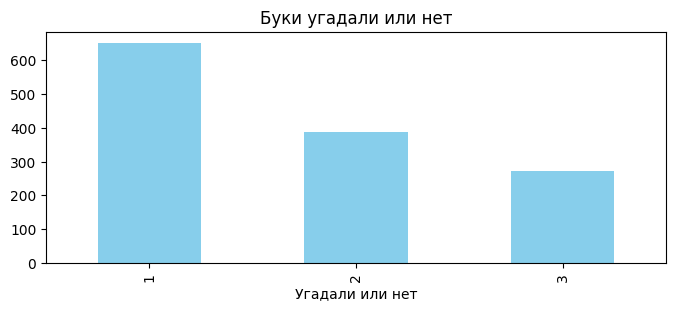

In [ ]:
plt.figure(figsize=(8, 3))
df['Угадали или нет'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Буки угадали или нет')
plt.show()

In [ ]:
value_counts = df['Угадали или нет'].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'Результат': {count}")

Количество значений '1' в столбце 'Результат': 652
Количество значений '2' в столбце 'Результат': 389
Количество значений '3' в столбце 'Результат': 271


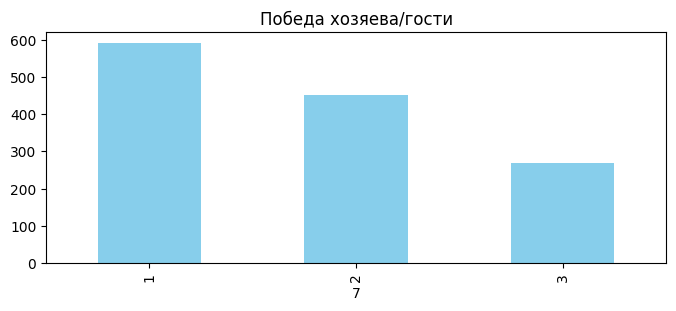

In [ ]:
plt.figure(figsize=(8, 3))
df[7].value_counts().plot(kind='bar', color='skyblue')
plt.title('Победа хозяева/гости')
plt.show()

In [ ]:
value_counts = df[7].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'Победа хозяева/гости': {count}")

Количество значений '1' в столбце 'Победа хозяева/гости': 592
Количество значений '2' в столбце 'Победа хозяева/гости': 452
Количество значений '3' в столбце 'Победа хозяева/гости': 268


0 - слабая команда

1- сильная команда

0-0=1

0-1=2

1-0=3

1-1=4

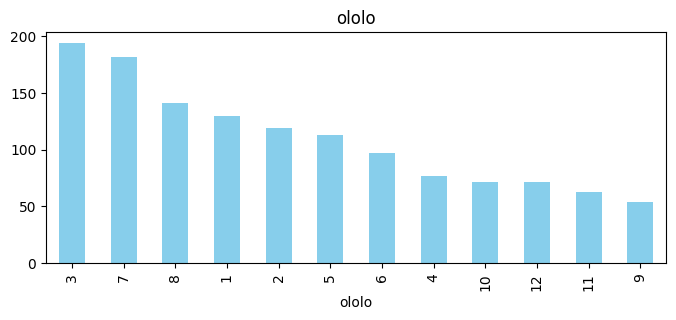

In [ ]:
plt.figure(figsize=(8, 3))
df['ololo'].value_counts().plot(kind='bar', color='skyblue')
plt.title('ololo')
plt.show()

1 - П1 две сильных

2 - П2 две слабых

3- П1 сильная\слабая

4 - ничья сильная\слабая

5 - П2 две сильных

6 - П1 слабая\сильная

7 - П2 слабая\сильная

8 - П1 две слабых

9 - ничья две слабых

10 - П2 сильная\слабая

11 - ничья слабая\сильная

12 - ничья две сильных

In [ ]:
value_counts = df['ololo'].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'ololo': {count}")

Количество значений '3' в столбце 'ololo': 194
Количество значений '7' в столбце 'ololo': 182
Количество значений '8' в столбце 'ololo': 141
Количество значений '1' в столбце 'ololo': 130
Количество значений '2' в столбце 'ololo': 119
Количество значений '5' в столбце 'ololo': 113
Количество значений '6' в столбце 'ololo': 97
Количество значений '4' в столбце 'ololo': 77
Количество значений '10' в столбце 'ololo': 71
Количество значений '12' в столбце 'ololo': 71
Количество значений '11' в столбце 'ololo': 63
Количество значений '9' в столбце 'ololo': 54


In [ ]:
value_counts = df['Результат'].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'Результат': {count}")

Количество значений '1' в столбце 'Результат': 562
Количество значений '2' в столбце 'Результат': 485
Количество значений '3' в столбце 'Результат': 265


In [ ]:
value_counts = df['Дата', 'Счет'].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'Счет': {count}")

Количество значений '3=2' в столбце 'Счет': 86
Количество значений '4=3' в столбце 'Счет': 81
Количество значений '3=4' в столбце 'Счет': 72
Количество значений '2=3' в столбце 'Счет': 70
Количество значений '4=1' в столбце 'Счет': 55
Количество значений '1=4' в столбце 'Счет': 55
Количество значений '2=5' в столбце 'Счет': 52
Количество значений '4=2' в столбце 'Счет': 51
Количество значений '1=2' в столбце 'Счет': 50
Количество значений '5=2' в столбце 'Счет': 46
Количество значений '2=4' в столбце 'Счет': 46
Количество значений '3=1' в столбце 'Счет': 42
Количество значений '2=1' в столбце 'Счет': 42
Количество значений '6=3' в столбце 'Счет': 37
Количество значений '5=4' в столбце 'Счет': 34
Количество значений '3=5' в столбце 'Счет': 30
Количество значений '1=3' в столбце 'Счет': 29
Количество значений '5=1' в столбце 'Счет': 28
Количество значений '4=0' в столбце 'Счет': 24
Количество значений '3=6' в столбце 'Счет': 24
Количество значений '4=5' в столбце 'Счет': 23
Количество зн

In [ ]:
value_counts = df['Хозяева'].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'Результат': {count}")

Количество значений '27' в столбце 'Результат': 41
Количество значений '22' в столбце 'Результат': 41
Количество значений '3' в столбце 'Результат': 41
Количество значений '15' в столбце 'Результат': 41
Количество значений '30' в столбце 'Результат': 41
Количество значений '26' в столбце 'Результат': 41
Количество значений '29' в столбце 'Результат': 41
Количество значений '23' в столбце 'Результат': 41
Количество значений '2' в столбце 'Результат': 41
Количество значений '32' в столбце 'Результат': 41
Количество значений '25' в столбце 'Результат': 41
Количество значений '1' в столбце 'Результат': 41
Количество значений '11' в столбце 'Результат': 41
Количество значений '18' в столбце 'Результат': 41
Количество значений '9' в столбце 'Результат': 41
Количество значений '21' в столбце 'Результат': 41
Количество значений '7' в столбце 'Результат': 41
Количество значений '24' в столбце 'Результат': 41
Количество значений '10' в столбце 'Результат': 41
Количество значений '17' в столбце '

In [ ]:
value_counts = df['Гости'].value_counts()

# Вывод результатов
for value, count in value_counts.items():
    print(f"Количество значений '{value}' в столбце 'Результат': {count}")

Количество значений '20' в столбце 'Результат': 41
Количество значений '31' в столбце 'Результат': 41
Количество значений '24' в столбце 'Результат': 41
Количество значений '1' в столбце 'Результат': 41
Количество значений '19' в столбце 'Результат': 41
Количество значений '5' в столбце 'Результат': 41
Количество значений '28' в столбце 'Результат': 41
Количество значений '7' в столбце 'Результат': 41
Количество значений '10' в столбце 'Результат': 41
Количество значений '16' в столбце 'Результат': 41
Количество значений '13' в столбце 'Результат': 41
Количество значений '2' в столбце 'Результат': 41
Количество значений '6' в столбце 'Результат': 41
Количество значений '4' в столбце 'Результат': 41
Количество значений '27' в столбце 'Результат': 41
Количество значений '12' в столбце 'Результат': 41
Количество значений '17' в столбце 'Результат': 41
Количество значений '22' в столбце 'Результат': 41
Количество значений '3' в столбце 'Результат': 41
Количество значений '8' в столбце 'Рез

#2026

##Кто победил хозяева/гости

In [ ]:
value_counts = df26['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 71 (40.11%)
Количество значений '2' в столбце 'Кто победил': 59 (33.33%)
Количество значений '3' в столбце 'Кто победил': 47 (26.55%)


##Угадали или нет

In [ ]:
value_counts = df26['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Угадали или нет': 74 (41.81%)
Количество значений '2' в столбце 'Угадали или нет': 56 (31.64%)
Количество значений '3' в столбце 'Угадали или нет': 47 (26.55%)


##Победа дома

In [ ]:
# Победа сильных дома

fh = df26[(df26['Кто победил'] == 1) & (df26['Угадали или нет'] == 1)]
# Вывод результата
#print(fh)

count = fh.shape[0]  # или len(fh)
print(count)

50


In [ ]:
# Среднее значение по кэфу

average_score1 = fh['П1'].mean()

print(f"Среднее значение по столбцу 'П1': {average_score1:.2f}")

Среднее значение по столбцу 'П1': 1.99


In [ ]:
# Победа слабых дома

sh = df26[(df26['Кто победил'] == 1) & (df26['Угадали или нет'] == 2)]
# Вывод результата
#print(sh)

count = sh.shape[0]  # или len(sh)
print(count)

21


In [ ]:
# Среднее значение по кэфу

average_score2 = sh['П1'].mean()

print(f"Среднее значение по столбцу 'П1': {average_score2:.2f}")

Среднее значение по столбцу 'П2': 2.87


##Победа в гостях

In [ ]:
# Победа фаворита в гостях

fv = df26[(df26['Кто победил'] == 2) & (df26['Угадали или нет'] == 1)]
# Вывод результата
#print(fv)

count = fv.shape[0]  # или len(fv)
print(count)

24


In [ ]:
# Среднее значение по кэфу

average_score3 = fv['П2'].mean()

print(f"Среднее значение по столбцу 'П2': {average_score3:.2f}")

Среднее значение по столбцу 'П2': 2.10


In [ ]:
# Победа слабых в гостях

sv = df26[(df26['Кто победил'] == 2) & (df26['Угадали или нет'] == 2)]
# Вывод результата
#print(sv)

count = sv.shape[0]  # или len(sv)
print(count)

35


In [ ]:
# Среднее значение по кэфу

average_score4 = sv['П2'].mean()

print(f"Среднее значение по столбцу 'П2': {average_score4:.2f}")

Среднее значение по столбцу 'П2': 3.04


## Ничья

In [ ]:
Draw = df26[(df26['Кто победил'] == 3) & (df26['Угадали или нет'] == 3)]
# Вывод результата
#print(Draw)

count = Draw.shape[0]  # или len(Draw)
print(count)

47


In [ ]:
# Среднее значение по кэфу

average_score5 = Draw['X'].mean()

print(f"Среднее значение по столбцу 'X': {average_score5:.2f}")

Среднее значение по столбцу 'X': 4.36


##Оъединение

In [ ]:
#Победа фаворита
result1 = pd.concat([fh, fv], axis=0)
number_of_rows = len(result1)
print("\nКоличество строк в объединенном DataFrame:", number_of_rows)


Количество строк в объединенном DataFrame: 74


In [ ]:
#Победа слабых
result2 = pd.concat([sh, sv], axis=0)
number_of_rows = len(result2)
print("\nКоличество строк в объединенном DataFrame:", number_of_rows)


Количество строк в объединенном DataFrame: 56
